In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


In [6]:
df=pd.read_csv('data/StudentsPerformance.csv')

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X,y=df.drop('math score',axis=1),df['math score']


In [10]:
numerical_cols=X.select_dtypes(exclude="object").columns.tolist()
categorical_cols=X.select_dtypes(include="object").columns.tolist()

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[
        ('StandardScaler',StandardScaler(),numerical_cols),
        ('OnehotEncoder',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ])

In [11]:
X=preprocessor.fit_transform(X)

In [12]:
X.shape

(1000, 19)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
def evaluate_model(true,pred):
    mse=mean_squared_error(true,pred)
    mae=mean_absolute_error(true,pred)
    rmse=np.sqrt(mse)
    r2=r2_score(true,pred)
    return mse,mae,rmse,r2

In [15]:
models={
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(),
    "Lasso Regression":Lasso(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "AdaBoost":AdaBoostRegressor(),
    "XGBoost":XGBRegressor(),
    "CatBoost":CatBoostRegressor(verbose=0),
    "Support Vector Regressor":SVR(),
    "KNeighbors Regressor":KNeighborsRegressor()
} 
model_report={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    mse,mae,rmse,r2=evaluate_model(y_test,y_pred)
    model_report[name]={
        "MSE":mse,
        "MAE":mae,
        "RMSE":rmse,
        "R2_Score":r2
    }

In [17]:
for model_name,metrics in model_report.items():
    print(f"Model: {model_name}")
    for metric_name,metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")
    print()

Model: Linear Regression
  MSE: 29.0952
  MAE: 4.2148
  RMSE: 5.3940
  R2_Score: 0.8804

Model: Ridge Regression
  MSE: 29.0563
  MAE: 4.2111
  RMSE: 5.3904
  R2_Score: 0.8806

Model: Lasso Regression
  MSE: 42.5063
  MAE: 5.1579
  RMSE: 6.5197
  R2_Score: 0.8253

Model: Decision Tree
  MSE: 59.2400
  MAE: 6.1700
  RMSE: 7.6968
  R2_Score: 0.7566

Model: Random Forest
  MSE: 36.5806
  MAE: 4.6398
  RMSE: 6.0482
  R2_Score: 0.8497

Model: AdaBoost
  MSE: 38.0220
  MAE: 4.8162
  RMSE: 6.1662
  R2_Score: 0.8437

Model: XGBoost
  MSE: 43.5039
  MAE: 5.1036
  RMSE: 6.5958
  R2_Score: 0.8212

Model: CatBoost
  MSE: 36.1037
  MAE: 4.6125
  RMSE: 6.0086
  R2_Score: 0.8516

Model: Support Vector Regressor
  MSE: 66.0420
  MAE: 5.4015
  RMSE: 8.1266
  R2_Score: 0.7286

Model: KNeighbors Regressor
  MSE: 52.6170
  MAE: 5.6190
  RMSE: 7.2538
  R2_Score: 0.7838



In [18]:
pd.DataFrame(model_report).T.sort_values(by="R2_Score",ascending=False)

,MSE,MAE,RMSE,R2_Score
Ridge Regression,29.056272,4.211101,5.390387,0.880593
Linear Regression,29.095170,4.214763,5.393994,0.880433
CatBoost,36.103658,4.612532,6.008632,0.851632
Random Forest,36.580575,4.639796,6.048188,0.849672
AdaBoost,38.021965,4.816167,6.166195,0.843749
Lasso Regression,42.506332,5.157879,6.519688,0.825320
XGBoost,43.503922,5.103630,6.595750,0.821221
KNeighbors Regressor,52.617000,5.619000,7.253758,0.783770
Decision Tree,59.240000,6.170000,7.696753,0.756553
Support Vector Regressor,66.042005,5.401539,8.126623,0.728600


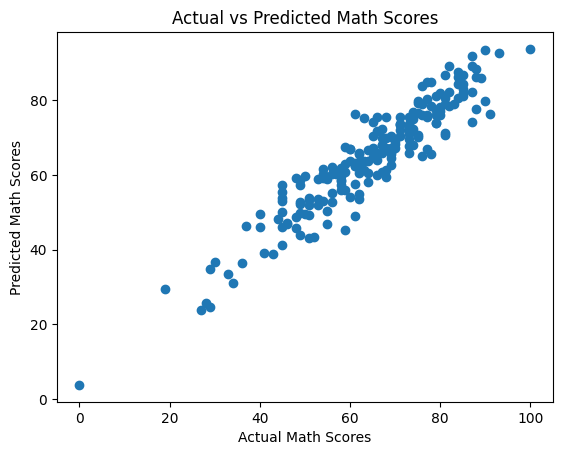

In [19]:
lin=LinearRegression()
lin.fit(X_train,y_train)
y_pred=lin.predict(X_test)
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Math Scores")
plt.ylabel("Predicted Math Scores")
plt.title("Actual vs Predicted Math Scores")
plt.show()


<Axes: xlabel='math score'>

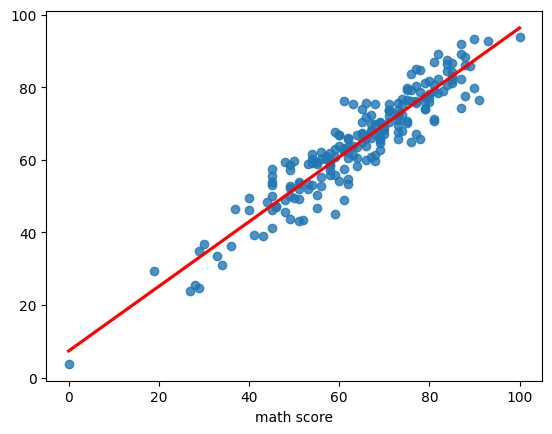

In [20]:
sns.regplot(x=y_test,y=y_pred,ci=None,line_kws={"color":"red"})

In [23]:
pred_df=pd.DataFrame({"Actual":y_test,"Predicted":y_pred,"Residuals":y_test - y_pred})
pred_df

,Actual,Predicted,Residuals
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
